# LSTM AUTOENCODER


In [2]:
import seaborn as sns
import matplotlib as mpl
import numpy as np
import torch
from scipy.io.arff import loadarff
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from scipy.io.arff import loadarff
from sklearn.metrics import confusion_matrix, classification_report
from glob import glob
import time 
import copy
import shutil
from torch import nn, optim
import torch.nn.functional as F
from torchvision import datasets, transforms, models 

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.2)
HAPPY_COLORS_PALETTE= ["#01BEFE", "#FFDD00", "#FF7D00", "#FF006D", "#ADFF02", "#8F00FF"]
sns.set_palette(sns.color_palette(HAPPY_COLORS_PALETTE))

mpl.rcParams['figure.figsize'] = 12,8

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)


In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') # checks if GPU is available Nvidia GPU and correct drivers installed? else run CPU GPU > CPU


Load Training and test data as pandas

In [4]:
with open('ECG5000/ECG5000_TRAIN.arff') as f:
    raw_data = loadarff(f)
    train = pd.DataFrame(raw_data[0])

with open('ECG5000/ECG5000_TEST.arff') as f:
    raw_data1 = loadarff(f)
    test = pd.DataFrame(raw_data1[0])
test.head()

,att1,att2,att3,att4,att5,att6,att7,att8,att9,att10,...,att132,att133,att134,att135,att136,att137,att138,att139,att140,target
0,3.690844,0.711414,-2.114091,-4.141007,-4.574472,-3.431909,-1.950791,-1.107067,-0.632322,0.334577,...,0.022847,0.188937,0.480932,0.629250,0.577291,0.665527,1.035997,1.492287,-1.905073,b'1'
1,-1.348132,-3.996038,-4.226750,-4.251187,-3.477953,-2.228422,-1.808488,-1.534242,-0.779861,-0.397999,...,1.570938,1.591394,1.549193,1.193077,0.515134,0.126274,0.267532,1.071148,-1.164009,b'1'
2,1.024295,-0.590314,-1.916949,-2.806989,-3.527905,-3.638675,-2.779767,-2.019031,-1.980754,-1.440680,...,0.443502,0.827582,1.237007,1.235121,1.738103,1.800767,1.816301,1.473963,1.389767,b'1'
3,0.545657,-1.014383,-2.316698,-3.634040,-4.196857,-3.758093,-3.194444,-2.221764,-1.588554,-1.202146,...,0.777530,1.119240,0.902984,0.554098,0.497053,0.418116,0.703108,1.064602,-0.044853,b'1'
4,0.661133,-1.552471,-3.124641,-4.313351,-4.017042,-3.005993,-1.832411,-1.503886,-1.071705,-0.521316,...,1.280823,1.494315,1.618764,1.447449,1.238577,1.749692,1.986803,1.422756,-0.357784,b'1'


Append the train and test datasets

In [5]:
df = pd.concat([train,test])
df.shape

(5000, 141)

Shuffle the dataset to ensure there is no ordering

In [6]:
df = df.sample(frac=1.0)

Dataset contains 5,000 time series examples (obtained with ECG) with 140 timesteps.

Each sequence corresponds to a single heartbeat from a single patient with congestive heart failure

5 types of heartbeats (classes):
1. Normal (N)
2. Premature Ventricular Contraction (PVC)
3. R-on-T Premature Ventricular Contraction (R-on-T PVC)
4. Supra-ventricular Premature or Ectopic Beat (SP or EB)
5. Unclassified Beat (UB)

Healthy typical rate is 70 to 75 beats per minute
Each cardiac cycle or heartbeat takes about 0.8 seconds to complete the cycle.
Frequency: 60-100 per minute (Humans) Duration: 0.6-1 second

We will be working with the normal data set

In [7]:
class_names = ['Normal', 'PVC', 'R on T', 'SP', 'UB']
new_columns = list(df.columns)
new_columns[-1] = 'target'
df.columns = new_columns

In [8]:
df. target.value_counts()

target
b'1'    2919
b'2'    1767
b'4'     194
b'3'      96
b'5'      24
Name: count, dtype: int64

C:\Users\DSA\AppData\Local\Temp\ipykernel_18428\3149716576.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(class_names)


Text(0.5, 1.0, 'Class Distribution')

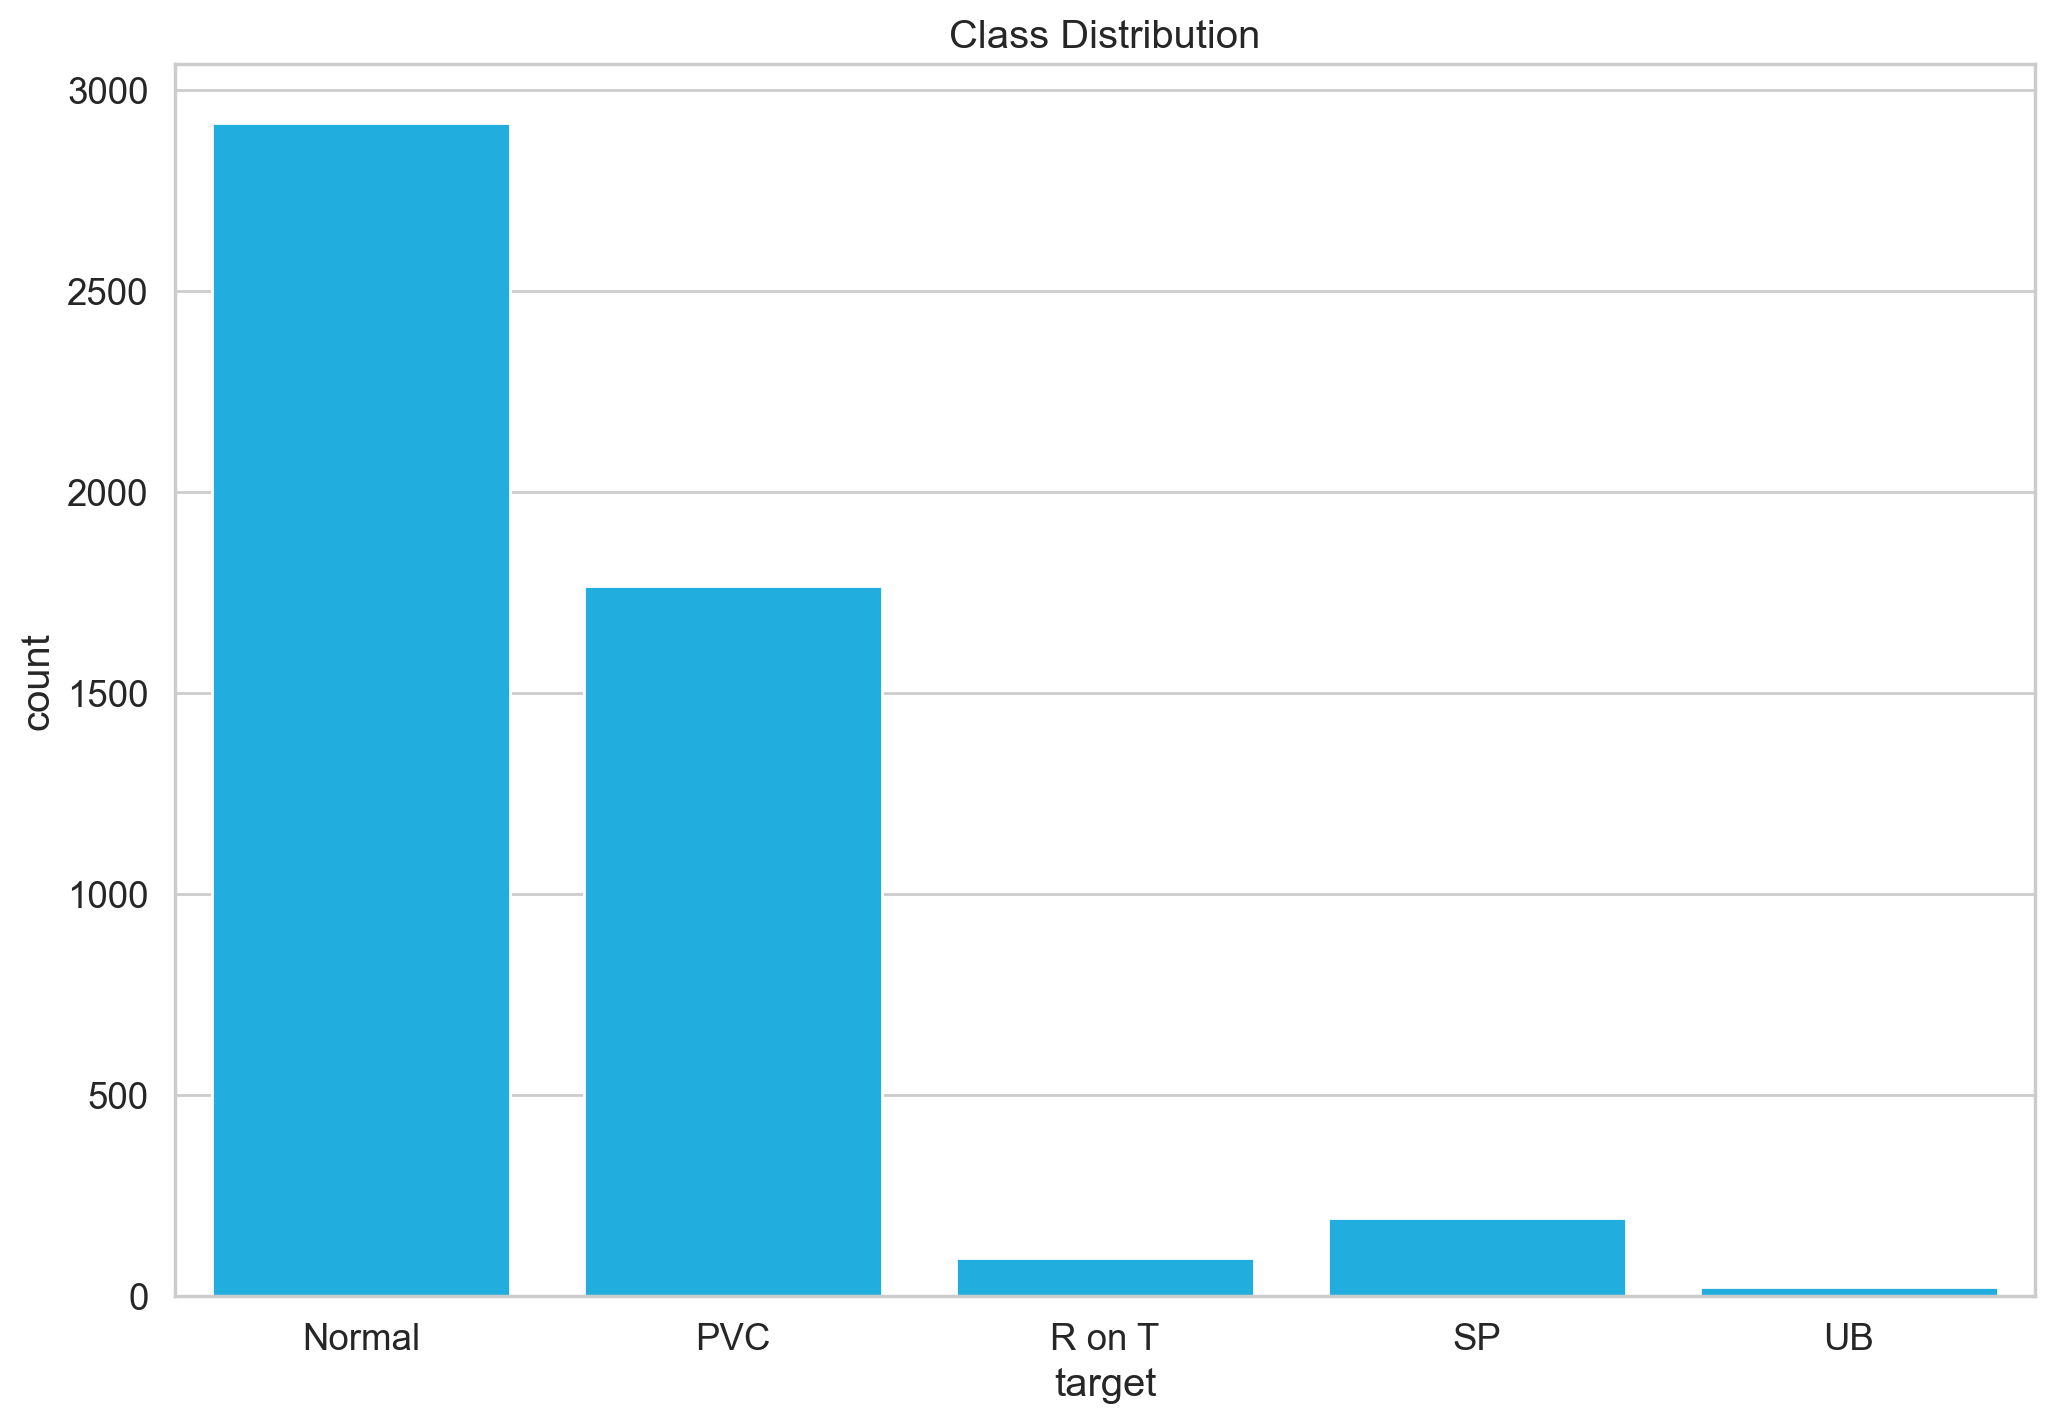

In [9]:
ax = sns.countplot(x=df['target'].astype(int))
ax.set_xticklabels(class_names)
ax.set_title("Class Distribution")

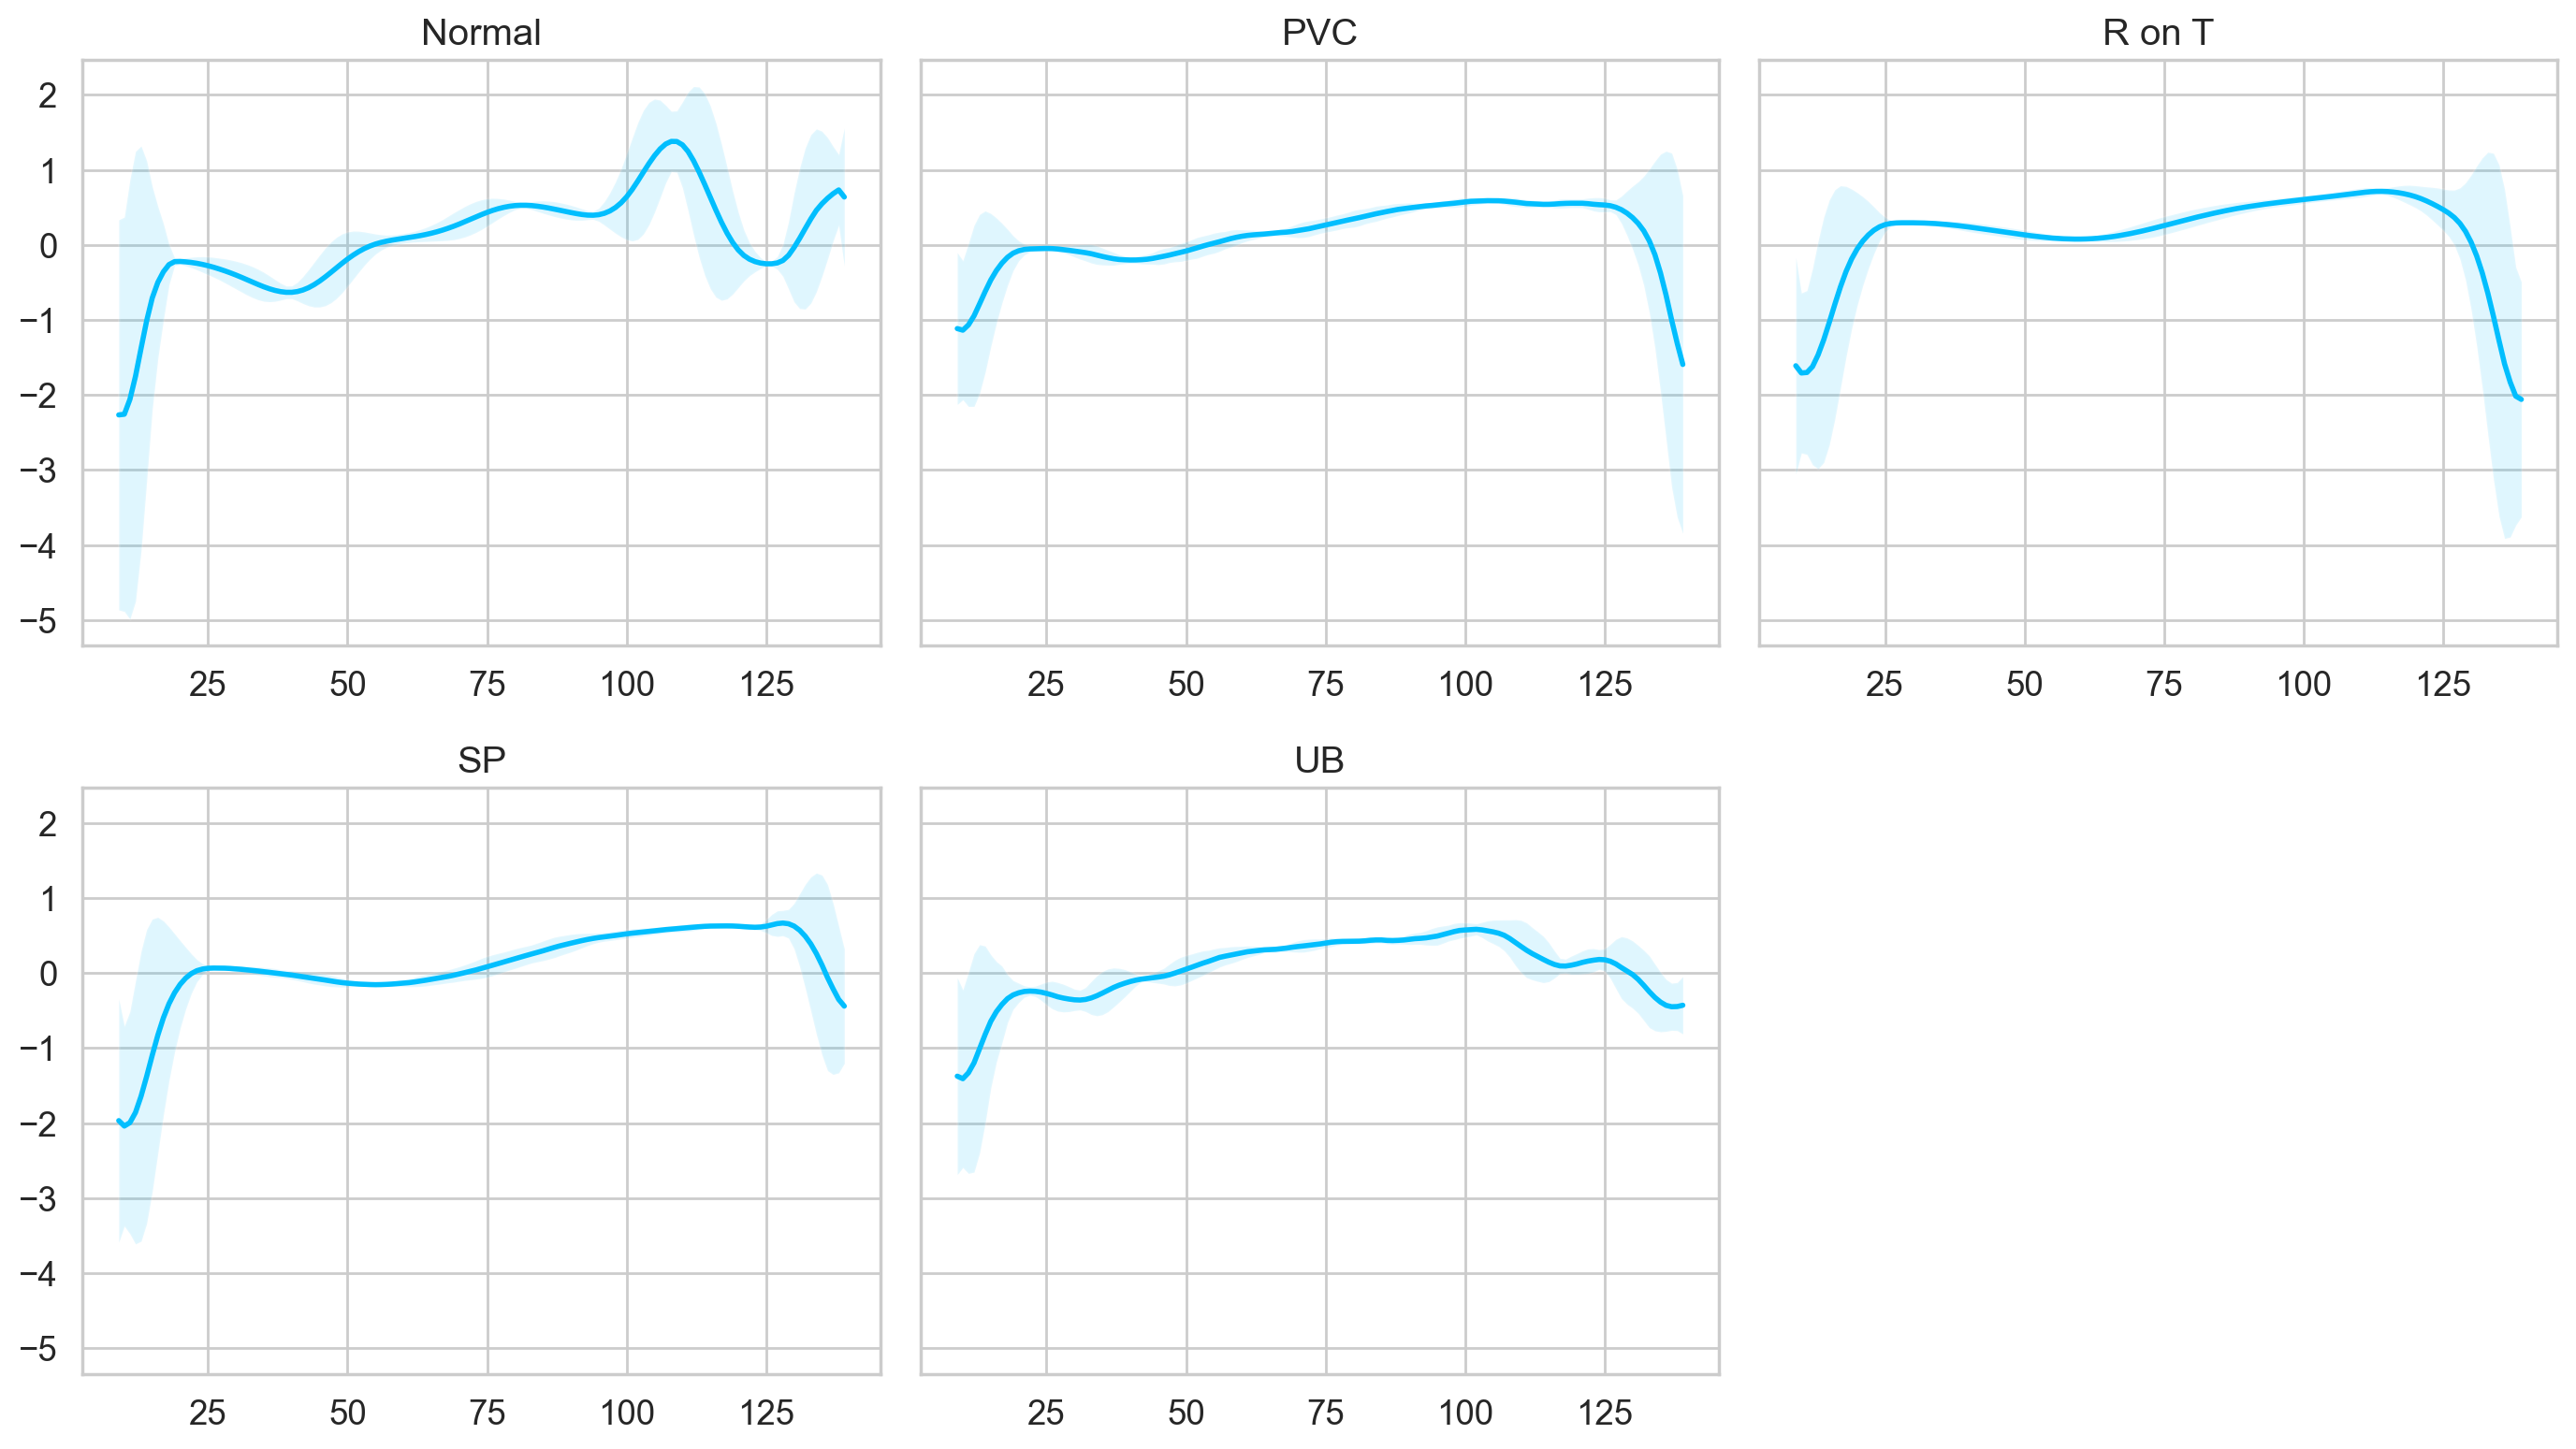

In [11]:
def plot_time_series_class(data, class_name, ax, n_steps=10):
    time_series_df = pd.DataFrame(data)

    smooth_path = time_series_df.rolling(n_steps).mean()
    path_deviation = 2 * time_series_df.rolling(n_steps).std()

    under_line = (smooth_path - path_deviation)[0]
    over_line = (smooth_path + path_deviation)[0]

    ax.plot(smooth_path, linewidth=2)
    ax.fill_between(
        path_deviation.index,
        under_line,
        over_line,
        alpha=.125
    )
    ax.set_title(class_name)

classes = df.target.unique()

fig,axs = plt.subplots(
    nrows=len(classes) // 3 + 1,
    ncols=3,
    sharey=True,
    figsize=(14,8)
)

for i, cls in enumerate(classes):
    ax = axs.flat[i]
    data = df[df.target == cls] \
    .drop(labels='target', axis=1) \
    .mean(axis=0) \
    .to_numpy()

    plot_time_series_class(data, class_names[i], ax)

fig.delaxes(axs.flat[-1])
fig.tight_layout()




Data Preprocessing to get all normal heartbeats and remove the target column

In [12]:
normal_df = df[df.target==b'1'].drop(labels='target', axis=1)
normal_df.shape

(2919, 140)

In [13]:
anomaly_df = df[df.target != b'1'].drop(labels='target', axis=1)
anomaly_df.shape

(2081, 140)

Splitting normal examples into the train, test and validation datasets

In [14]:
train_df, val_df = train_test_split(
    normal_df,
    test_size=0.15,
    random_state=RANDOM_SEED
)

val_df, test_df = train_test_split(
    val_df,
    test_size=0.33,
    random_state=RANDOM_SEED
)

Converting to tensors

In [15]:
def create_dataset(df):
    sequences = df.astype(np.float32).to_numpy().tolist()
    dataset = [torch.tensor(s).unsqueeze(1).float() for s in sequences]
    n_seq, seq_len, n_features = torch.stack(dataset).shape

    return dataset, seq_len, n_features

Each time series will be converted to a 2D Tensor in the shape sequence length x number of features (140x1 in our case)

In [16]:
train_dataset, seq_len, n_features = create_dataset(train_df)
val_dataset, _, _ = create_dataset(val_df)
test_normal_dataset, _, _ = create_dataset(test_df)
test_anomaly_dataset, _, _ = create_dataset(anomaly_df)



General Autoencoder architecture consists of two components:
- Encoder compresses the input
- Decoder tries to reconstruct it

Encoder and Decoder class

In [ ]:
# Encoder is 2 separate layers of the LSTM RNN

class Encoder(nn.Module):
    def __init__(self, seq_len, n_features, embedding_dim=64):
        super(Encoder,self).__init__()

        self.seq_len, self.n_features = seq_len, n_features
        self.embedding_dim, self.hidden_dim = embedding_dim, 2 * embedding_dim

        self.rnn1 = nn.LSTM(
            input_size=n_features,
            hidden_size=self.hidden_dim,
            num_layers=1,
            batch_first=True
        )

        # Initializing the hidden number of layers
        self.rnn2 = nn.LSTM(
            input_size=self.hidden_dim,
            hidden_size=embedding_dim,
            num_layers=1,
            batch_first=True
        )
    
    def forward(self,x):
        x = x.reshape((1, self.seq_len, self.n_features))

        x, (_, _) = self.rnn1(x)
        x, (hidden_n, _) = self.rnn2(x)

        return hidden_n.reshape((self.n_features, self.embedding_dim))

In [16]:
class Decoder(nn.Module):
    def __init__(self, seq_len, input_dim=64, n_features=1):
        super(Decoder, self).__init__()

        self.seq_len, self.input_dim = seq_len, input_dim
        self.hidden_dim, self.n_features = 2 * input_dim, n_features

        self.rnn1 = nn.LSTM(
            input_size=input_dim,
            hidden_size=input_dim,
            num_layers=1,
            batch_first=True
        )

        # Using a dense layer as an output layer
        self.rnn2 = nn.LSTM(
            input_size=input_dim,
            hidden_size=self.hidden_dim,
            num_layers=1,
            batch_first=True
        )

        self.output_layer = nn.Linear(self.hidden_dim, n_features)

    def forward(self,x):
        x = x.repeat(self.seq_len, self.n_features)
        x = x.reshape((self.n_features, self.seq_len, self.input_dim))

        x, (hidden_n, cell_n) = self.rnn1(x)
        x, (hidden_n, cell_n) = self.rnn2(x)
        x = x.reshape((self.seq_len, self.hidden_dim))

        return self.output_layer(x)
    

The Decoder contains two LSTM layers and an output layer that gives the final reconstruction

In [17]:
class RecurrentAutoencoder(nn.Module):
    def __init__(self, seq_len, n_features, embedding_dim=64):
        super(RecurrentAutoencoder, self).__init__()
        self.encoder = Encoder( seq_len, n_features, embedding_dim).to(device)
        self.decoder = Decoder(seq_len, embedding_dim, n_features).to(device)

    def forward(self,x):
        x = self.encoder(x)
        x = self.decoder(x)

        return x

Create model instance

In [18]:
model = RecurrentAutoencoder(seq_len, n_features, 128) 
model = model.to(device)

Building a Training model

In [19]:
def train_model(model, train_dataset, val_dataset, n_epochs):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.L1Loss(reduction='sum').to(device)
    history = dict(train=[], val=[])

    best_model_wts = copy.deepcopy(model.state_dict())
    best_loss = 10000.0

    for epoch in range(1, n_epochs + 1):
        model = model.train()

        train_losses =[]
        for seq_true in train_dataset:
            optimizer.zero_grad()
            seq_true = seq_true.to(device)
            seq_pred = model(seq_true)
            loss = criterion(seq_pred, seq_true)
            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())

        # Next we need to evaluate the dataset
        val_losses = []
        model = model.eval()
        
        with torch.no_grad():
            for seq_true in val_dataset:
                seq_true = seq_true.to(device)
                seq_pred = model(seq_true)
                loss = criterion(seq_pred, seq_true)
                val_losses.append(loss.item())
                
        train_loss = np.mean(train_losses)
        val_loss = np.mean(val_losses)
        history['train'].append(train_loss)
        history['val'].append(val_loss)

        if val_loss < best_loss:
            best_loss = val_loss 
            best_model_wts = copy.deepcopy(model.state_dict())
    
        print(f'Epoch {epoch}: train loss {train_loss} val loss {val_loss}')

    model.load_state_dict(best_model_wts)
    return model.eval(), history


Training

In [20]:
model,history = train_model(model, train_dataset, val_dataset, n_epochs=150)

Epoch 1: train loss 71.09713615346753 val loss 56.04317706111348
Epoch 2: train loss 55.33473672601591 val loss 54.96657506272248
Epoch 3: train loss 54.803356071481396 val loss 58.183095756244334
Epoch 4: train loss 53.95722370309149 val loss 45.01773430625733
Epoch 5: train loss 42.29659668354679 val loss 41.850554287230196
Epoch 6: train loss 41.044363367418185 val loss 49.06635985520919
Epoch 7: train loss 36.99495652816508 val loss 35.558313340457225
Epoch 8: train loss 32.01255727073734 val loss 32.15355357212418
Epoch 9: train loss 42.32447367471728 val loss 56.21103914280393
Epoch 10: train loss 53.23479509488175 val loss 49.081127609409165
Epoch 11: train loss 42.98521374868126 val loss 38.14697140312846
Epoch 12: train loss 37.29610409058183 val loss 38.787149813394905
Epoch 13: train loss 35.4861477813813 val loss 39.43886706121139
Epoch 14: train loss 49.023647730026646 val loss 49.9345481534053
Epoch 15: train loss 48.96766896461201 val loss 49.75782310433762
Epoch 16: tra


This function helps to go through the examples in the dataset and record the predictions and losses in the dataset.

<Axes: ylabel='Density'>

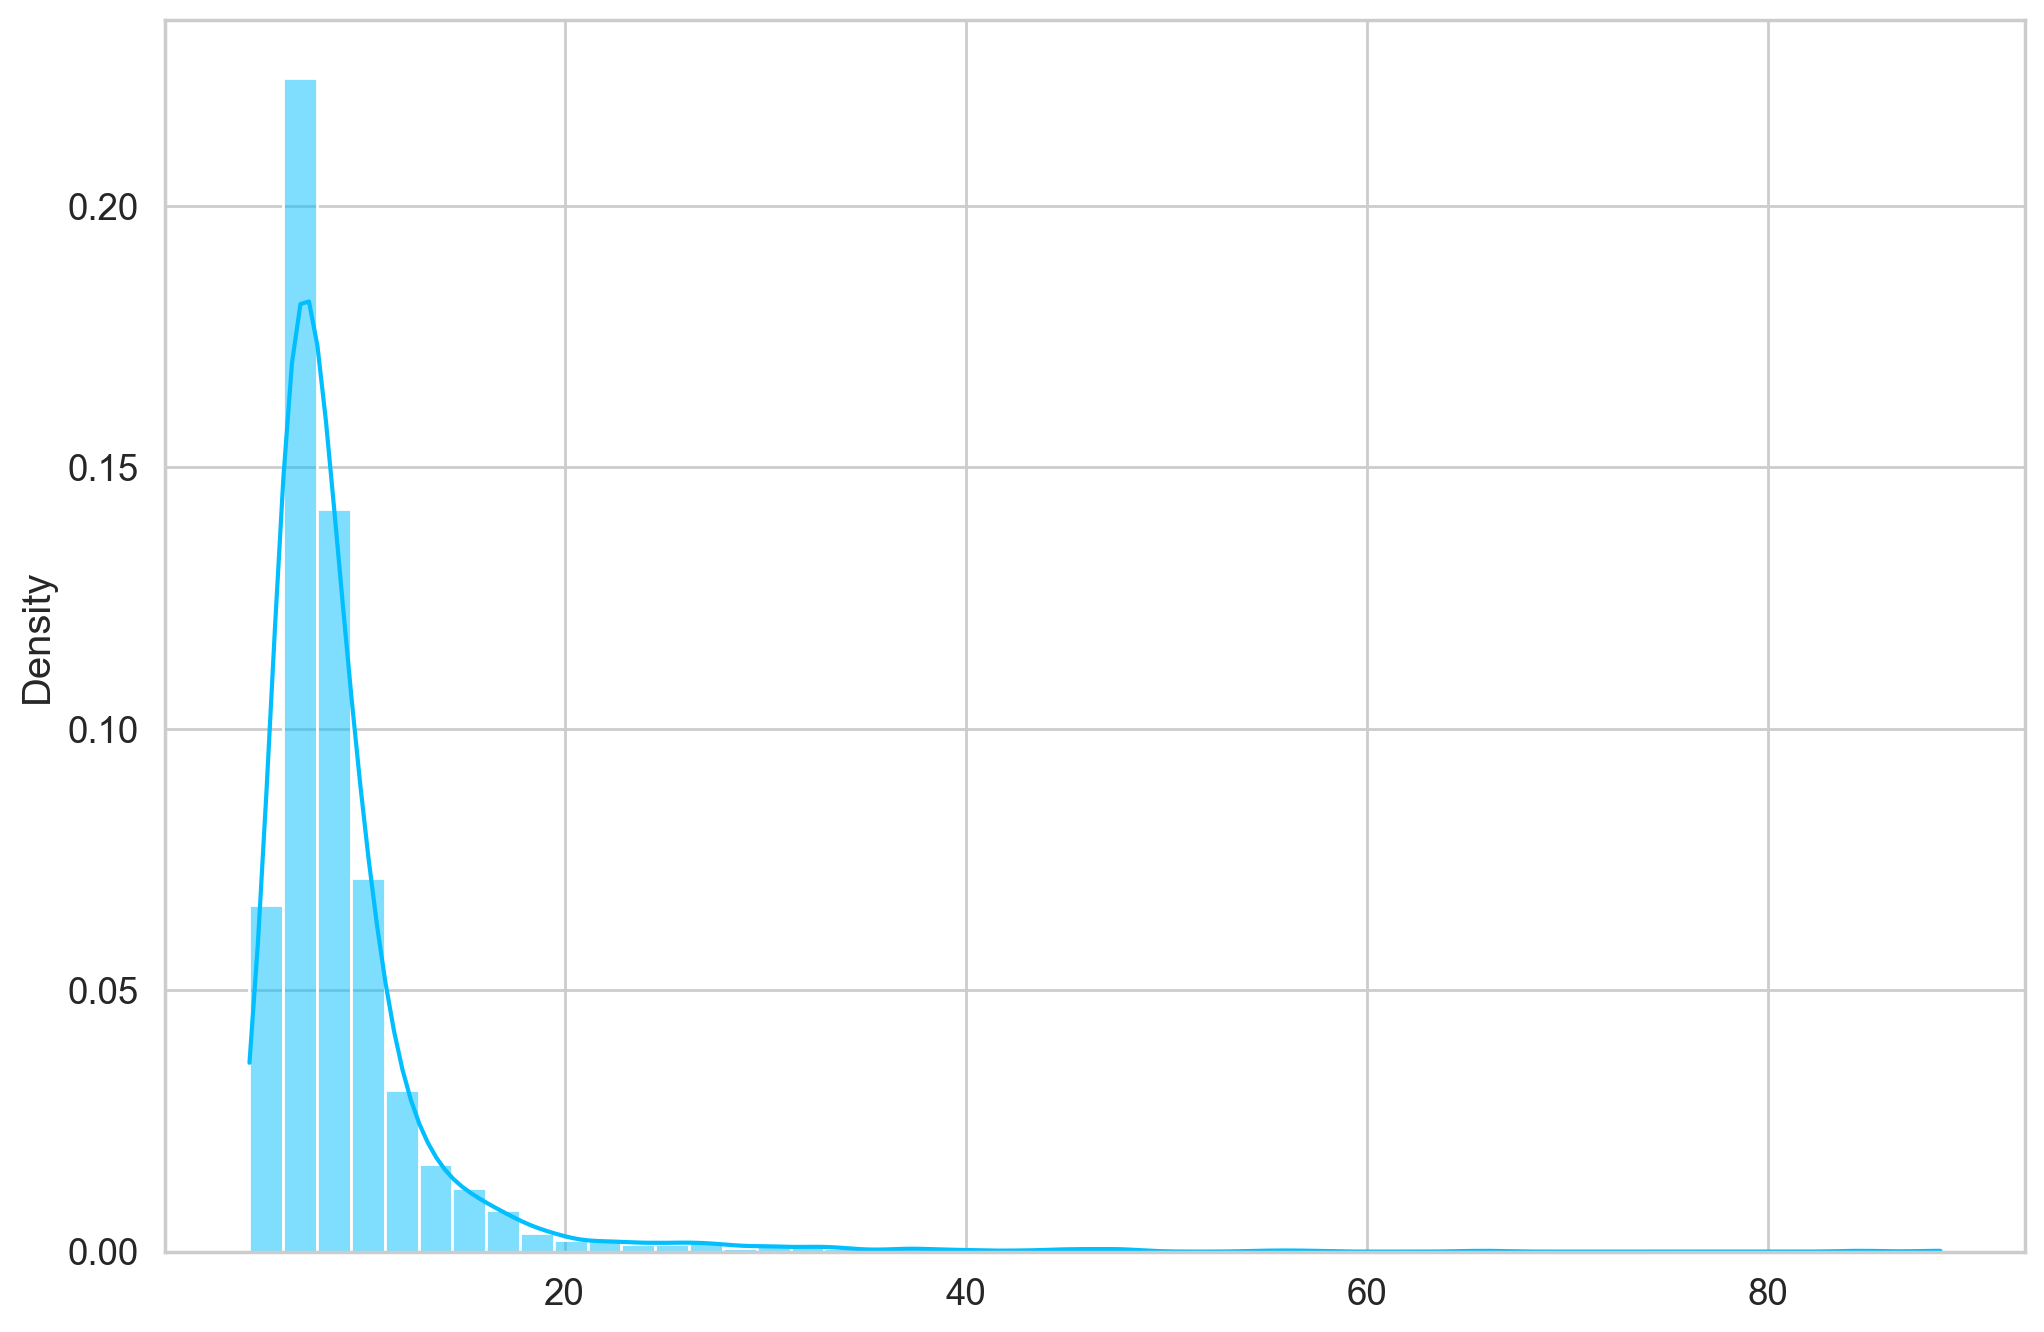

In [21]:
def predict(model, dataset):
    predictions, losses = [], []
    criterion = nn.L1Loss(reduction='sum').to(device)

    with torch.no_grad():
        model = model.eval()
        for seq_true in dataset:
            seq_true = seq_true.to(device)
            seq_pred = model(seq_true)
    
            loss = criterion(seq_pred, seq_true)
            predictions.append(seq_pred.cpu().numpy().flatten())
            losses.append(loss.item())
    
    return predictions, losses 

_, losses = predict(model, train_dataset)
sns.histplot(losses, bins=50, kde=True, stat="density")


Evaluation using threshold.

<Axes: ylabel='Density'>

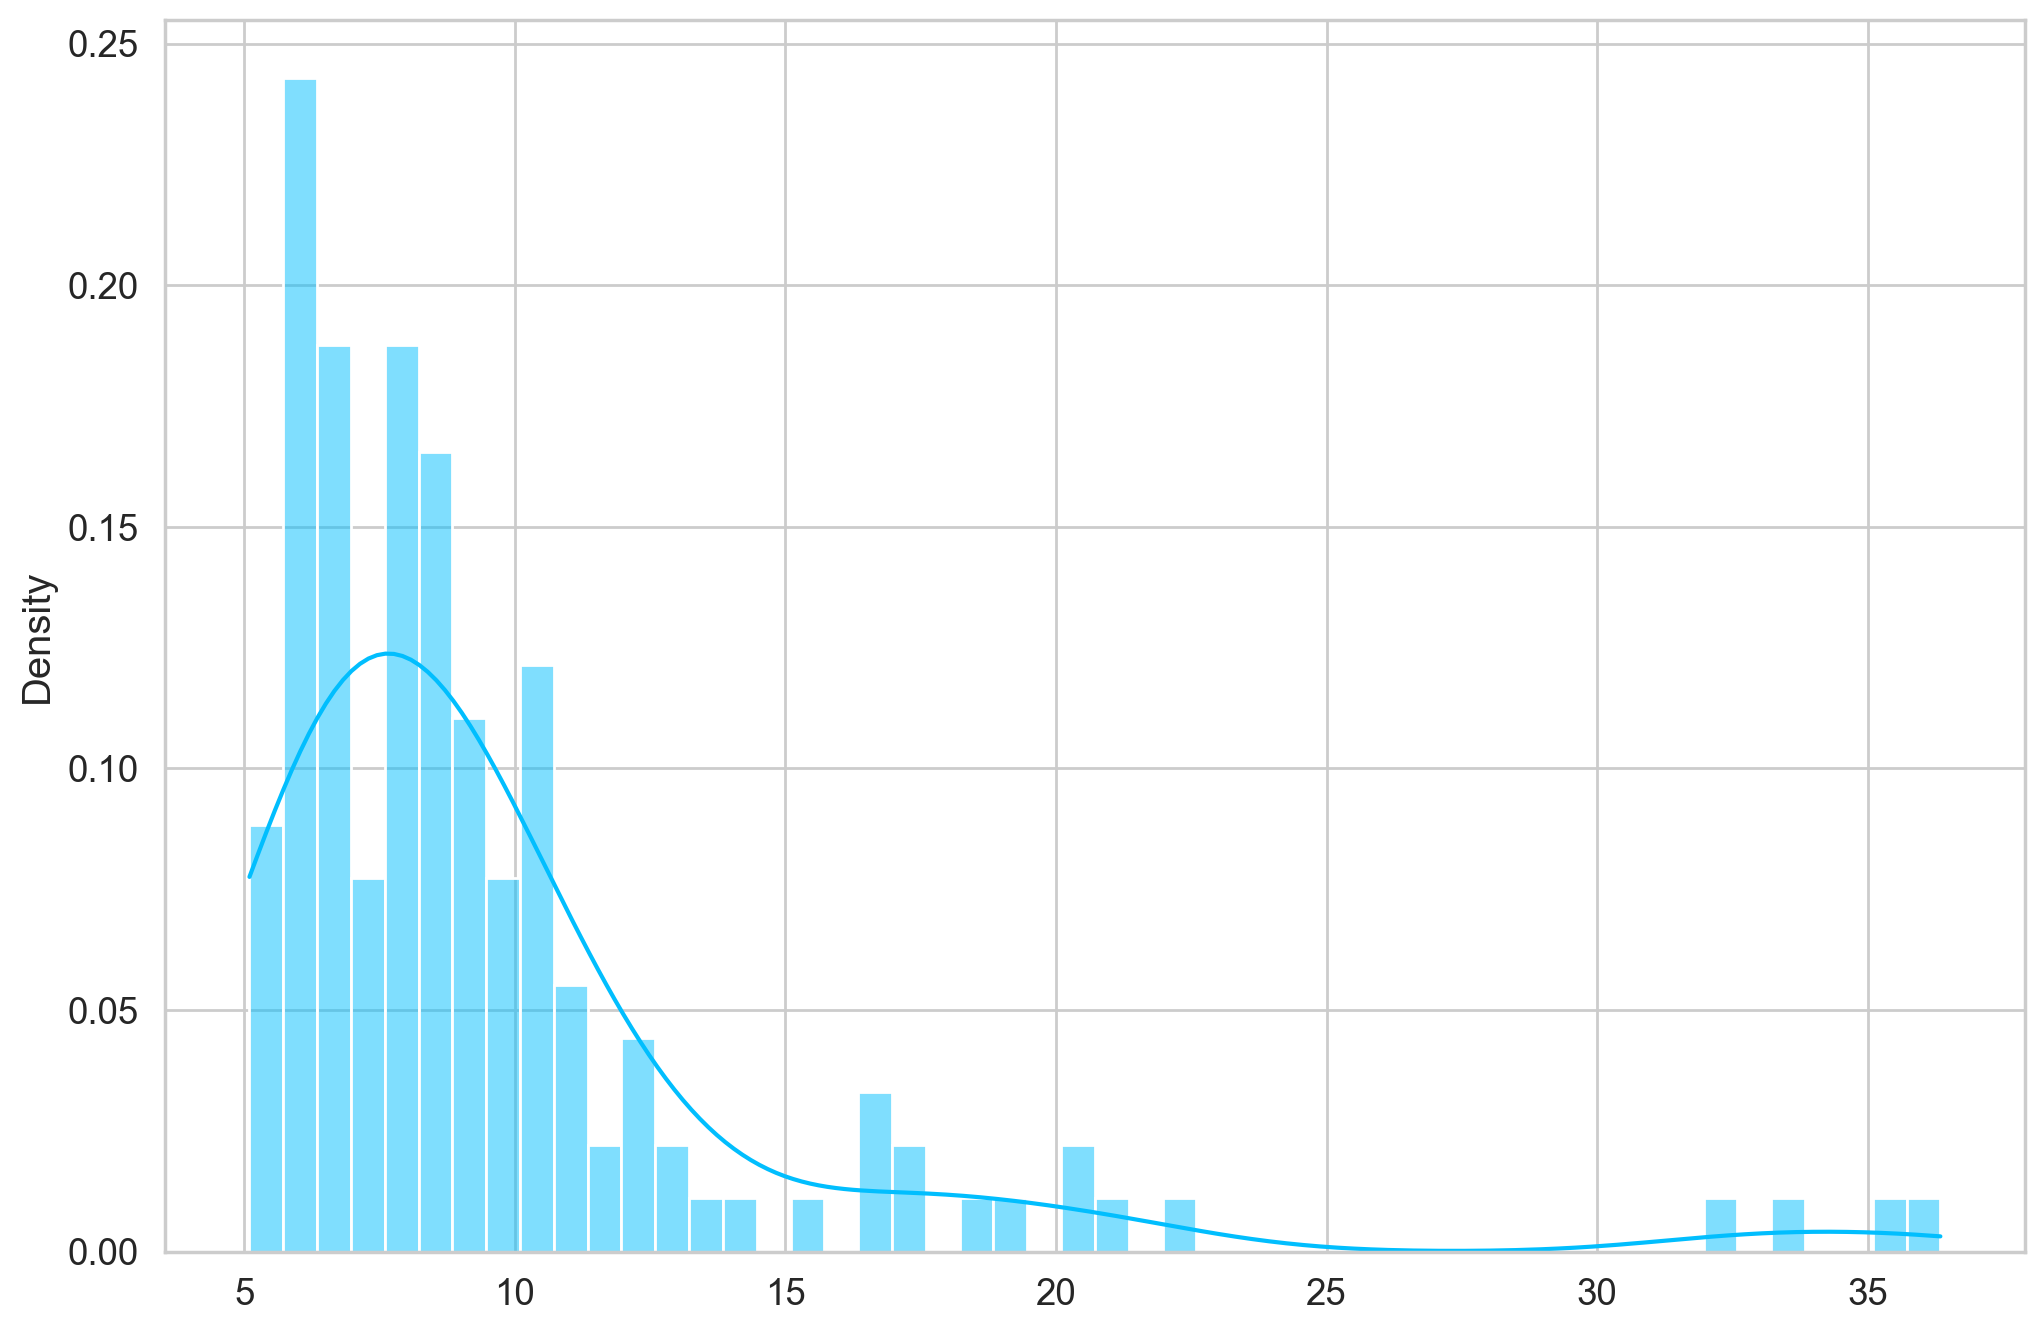

In [22]:
predictions, pred_losses = predict(model, test_normal_dataset)
sns.histplot(pred_losses, bins=50, kde=True, stat='density')

We can count the predictions

In [26]:
THRESHOLD = 29
correct = sum(l <= THRESHOLD for l in pred_losses)
print(f'Correct normal predictions {correct}/{len(test_normal_dataset)}')



NameError: name 'pred_losses' is not defined

In [24]:
anomaly_dataset = test_anomaly_dataset[:len(test_normal_dataset)]

<Axes: ylabel='Density'>

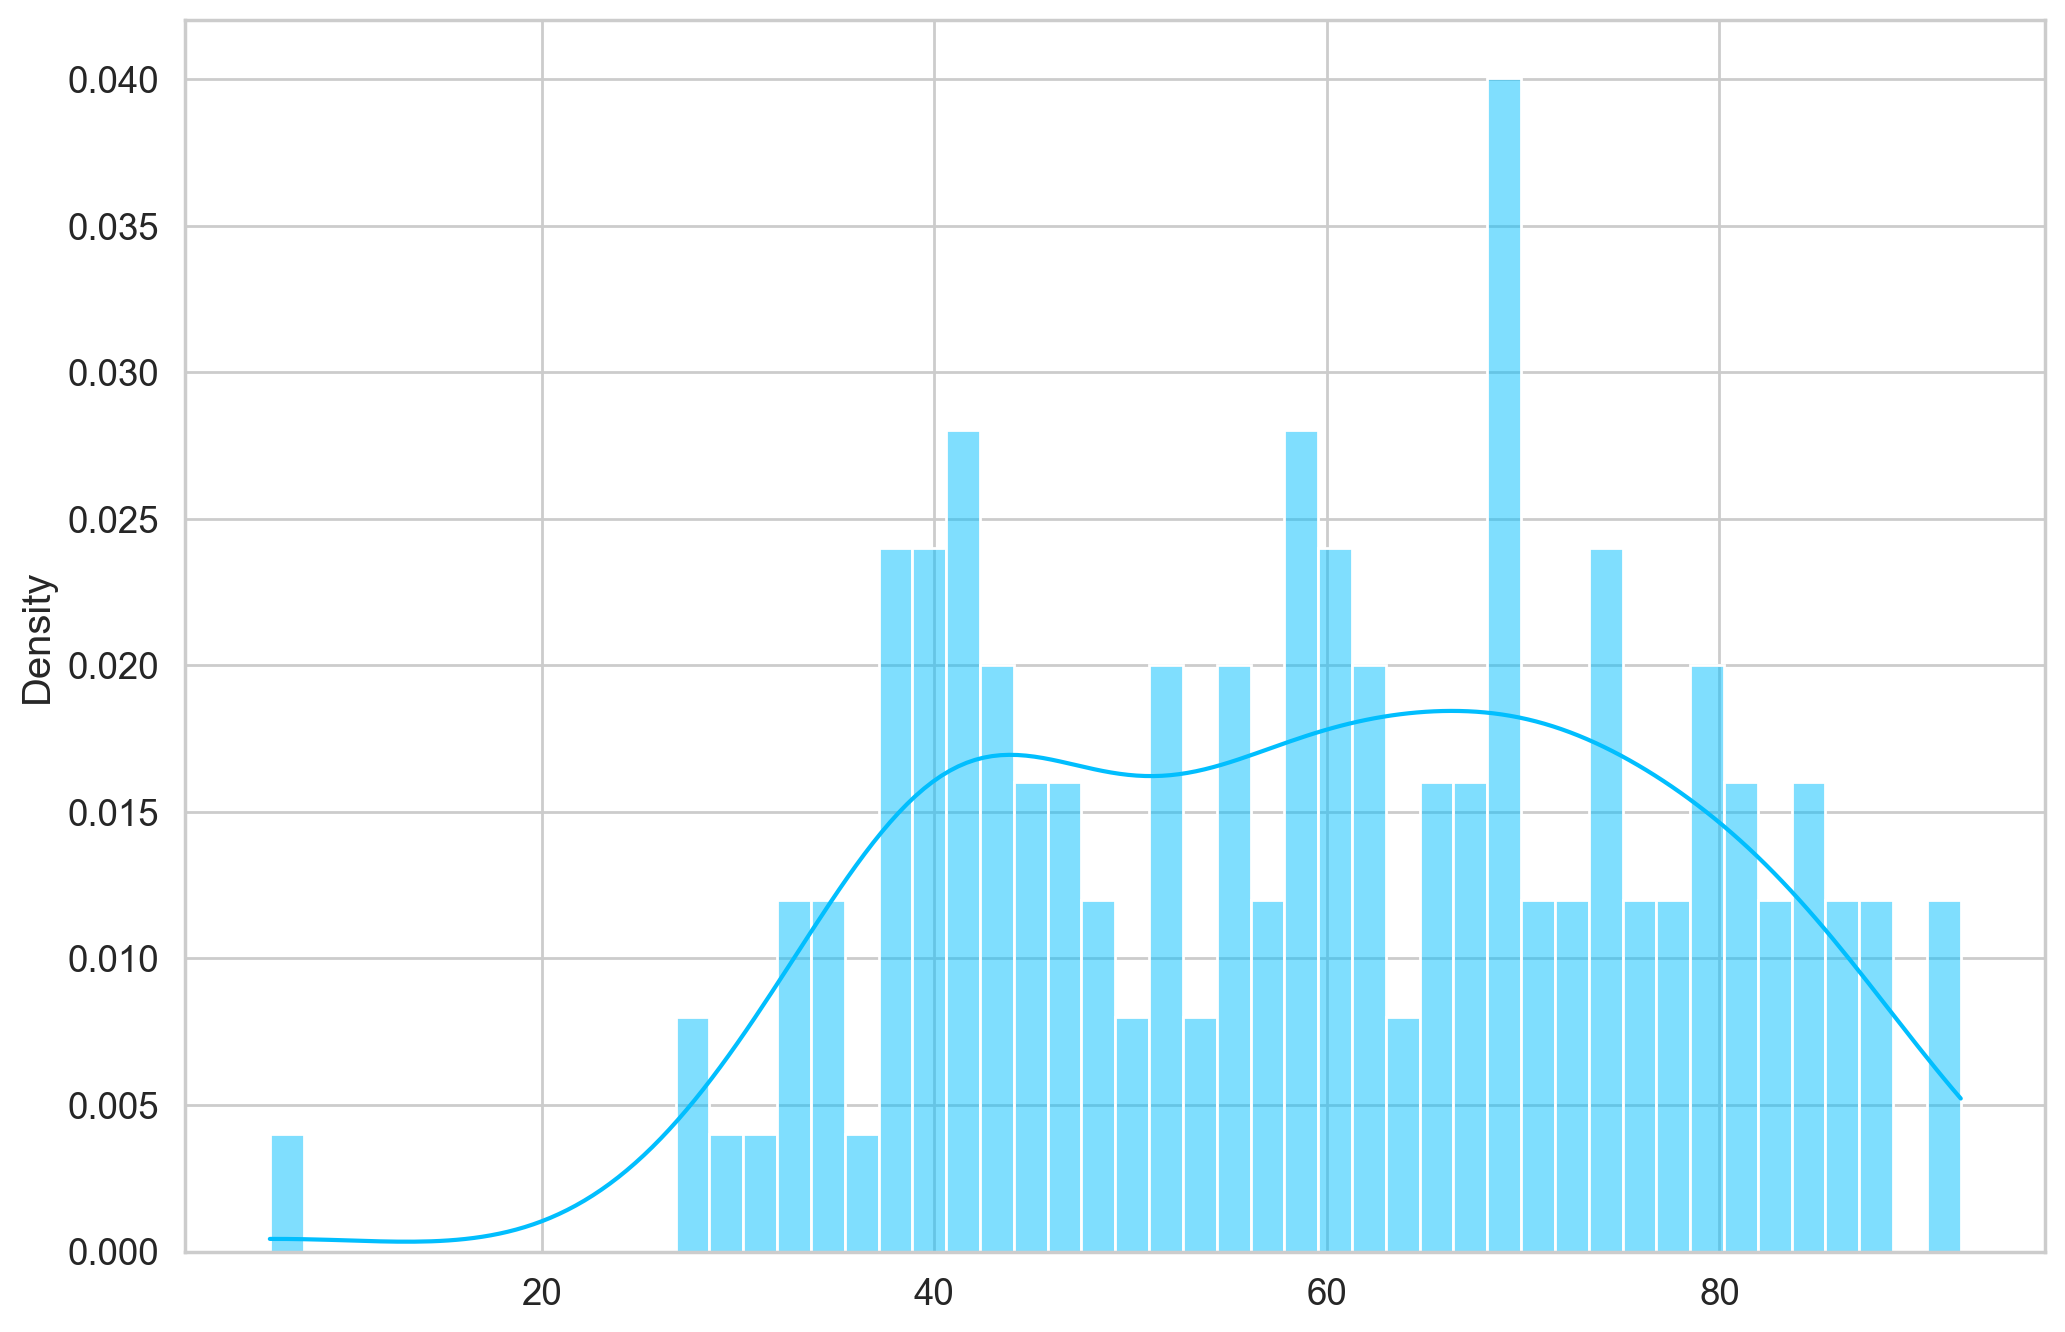

In [25]:
predictions, pred_losses = predict (model,anomaly_dataset)
sns.histplot(pred_losses, bins=50, kde=True, stat='density')


We can count the number of examples in the threshold

In [26]:
correct = sum(l > THRESHOLD for l in pred_losses)
print(f'Correct anomaly predictions: {correct}/{len(anomaly_dataset)}')


Correct anomaly predictions: 142/145


Reconstruction error graphs

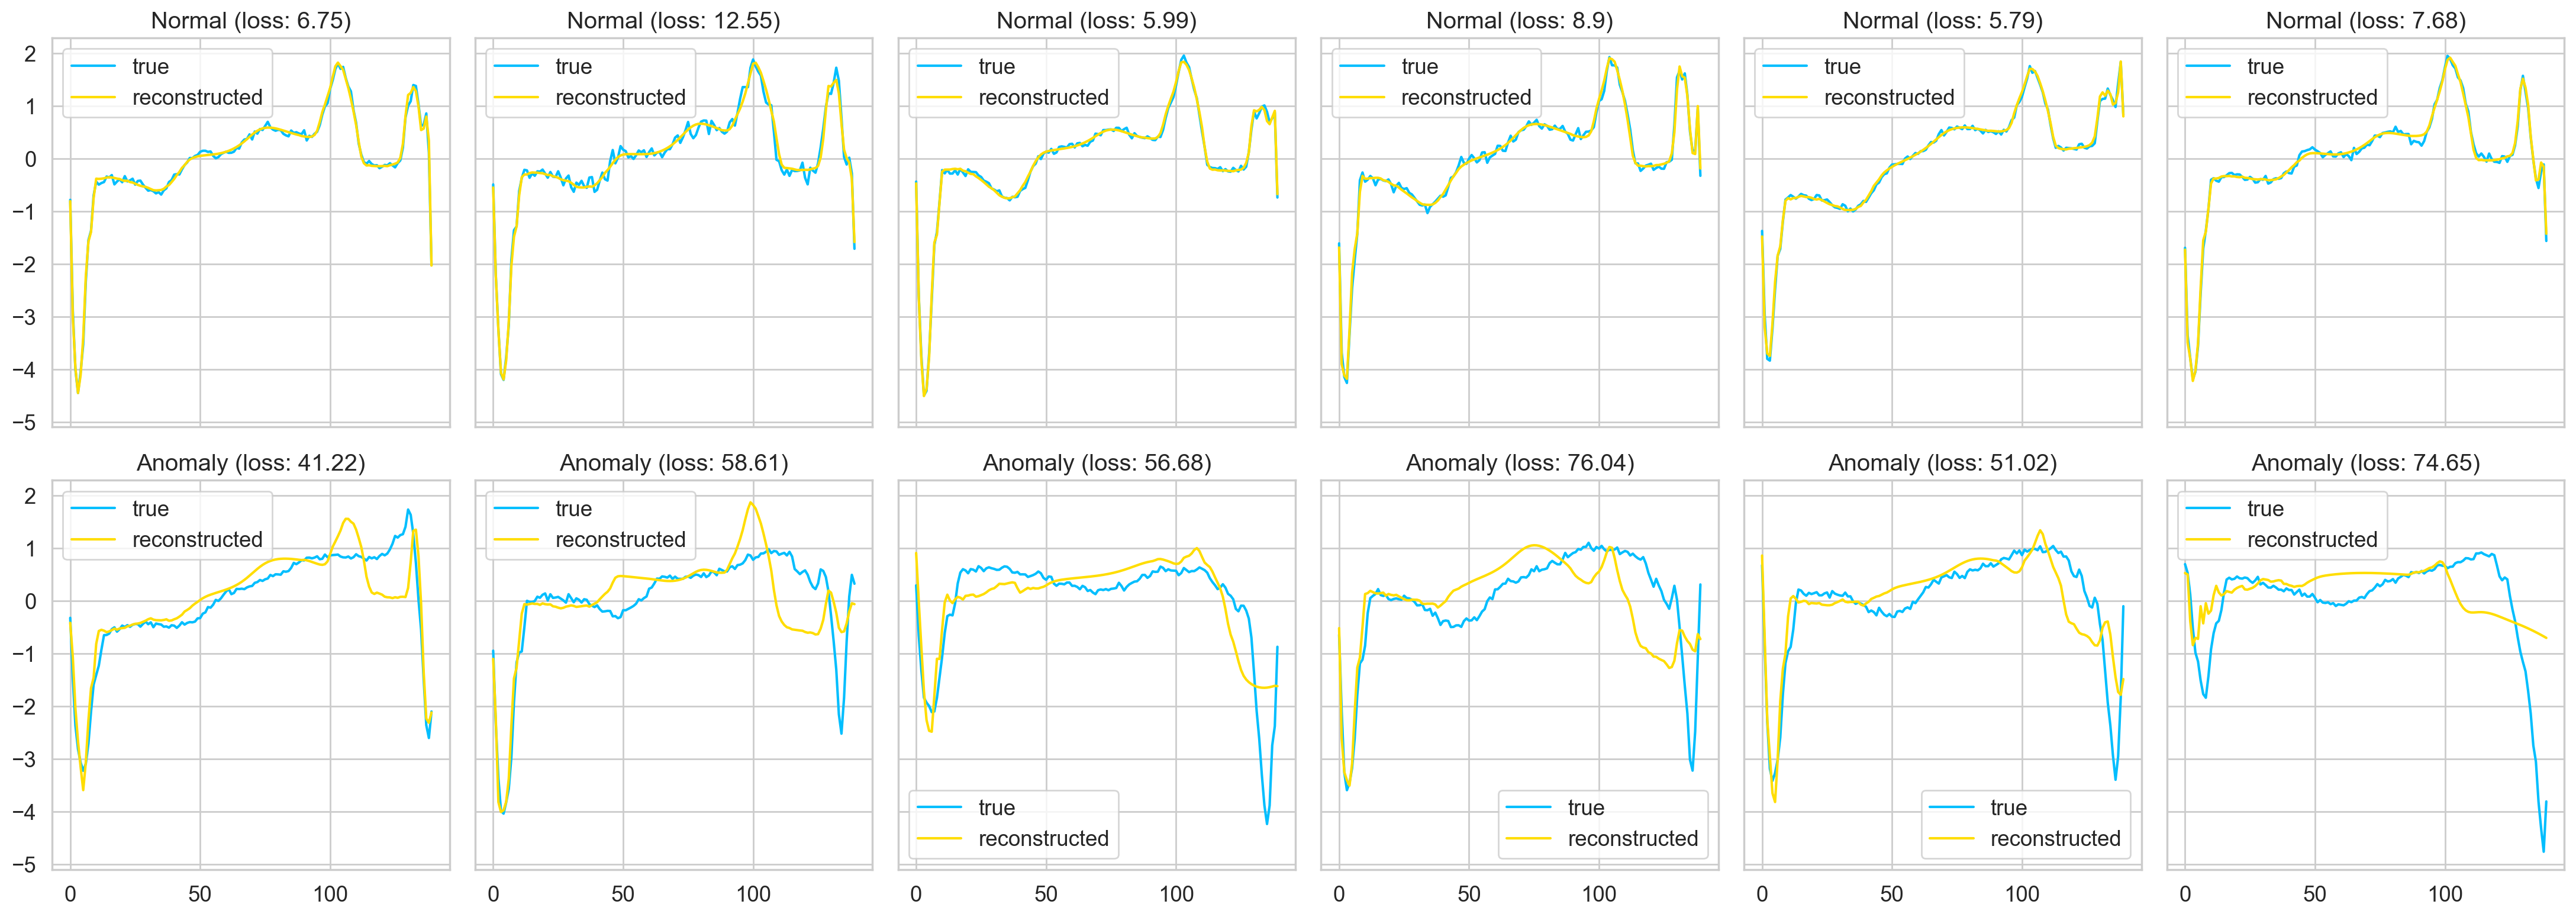

In [27]:
def plot_prediciton(data, model, title, ax):
    predictions, pred_losses = predict(model, [data])

    ax.plot(data, label='true')
    ax.plot(predictions[0], label='reconstructed')
    ax.set_title(f'{title} (loss: {np.around(pred_losses[0], 2)})')
    ax.legend()

fig, axs = plt.subplots(
    nrows=2,
    ncols=6,
    sharey=True,
    sharex=True,
    figsize=(22,8)
)

for i, data in enumerate(test_normal_dataset[:6]):
    plot_prediciton(data, model, title='Normal', ax=axs[0,i])

for i, data in enumerate(test_anomaly_dataset[:6]):
    plot_prediciton(data, model, title='Anomaly', ax=axs[1,i])

fig.tight_layout()

In [28]:
print(f"MEAN:  {train_df.mean().mean()}")
print(f"STD:  {train_df.std().mean()}")

MEAN:  -1.1320975902760567e-11
STD:  0.3953759541691663


ONNX model conversions

In [29]:
import torch
torch.save(model, 'model.pth')

In [30]:
torch.save(model.state_dict(), 'lstm_weights.pth')
print("Successful")

Successful


In [ ]:
# ONNX conversion
sample_input = torch.randn(1,140,1).to(device)

torch.onnx.export(model,
                  sample_input,
                  "lstm_autoencoder.onnx",
                  export_params=True,
                  opset_version=15,
                  do_constant_folding=True,
                  input_names = ['input'],
                  output_names=['output'])

print("ONNX model exported.")

W0323 20:41:08.547000 17216 site-packages\torch\onnx\_internal\exporter\_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 15 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0323 20:41:09.025000 17216 site-packages\torch\onnx\_internal\exporter\_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0323 20:41:09.027000 17216 site-packages\torch\onnx\_internal\exporter\_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_sc

[torch.onnx] Obtain model graph for `RecurrentAutoencoder([...]` with `torch.export.export(..., strict=False)`...


c:\Users\DSA\AppData\Local\Programs\Python\Python312\Lib\contextlib.py:144: UserWarning: The tensor attributes self.decoder.rnn1._flat_weights[0], self.decoder.rnn1._flat_weights[1], self.decoder.rnn1._flat_weights[2], self.decoder.rnn1._flat_weights[3], self.decoder.rnn2._flat_weights[0], self.decoder.rnn2._flat_weights[1], self.decoder.rnn2._flat_weights[2], self.decoder.rnn2._flat_weights[3], self.encoder.rnn1._flat_weights[0], self.encoder.rnn1._flat_weights[1], self.encoder.rnn1._flat_weights[2], self.encoder.rnn1._flat_weights[3], self.encoder.rnn2._flat_weights[0], self.encoder.rnn2._flat_weights[1], self.encoder.rnn2._flat_weights[2], self.encoder.rnn2._flat_weights[3] were assigned during export. Such attributes must be registered as buffers using the `register_buffer` API (https://pytorch.org/docs/stable/generated/torch.nn.Module.html#torch.nn.Module.register_buffer).
  next(self.gen)


[torch.onnx] Obtain model graph for `RecurrentAutoencoder([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


c:\Users\DSA\AppData\Local\Programs\Python\Python312\Lib\copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 15).


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 2 of general pattern rewrite rules.
ONNX model exported.


# Evaluation

In [35]:
import numpy as np
import pandas as pd
import onnxruntime as ort
from scipy.io.arff import loadarff
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

ONNX_MODEL_PATH = "lstm_autoencoder.onnx"
session = ort.InferenceSession(ONNX_MODEL_PATH)
input_name = session.get_inputs()[0].name
print(f"Input name: {input_name}")
print(f"Input shape: {session.get_inputs()[0].shape}")
print(f"Output shape: {session.get_outputs()[0].shape}\n")

Input name: input
Input shape: [1, 140, 1]
Output shape: [140, 1]



In [36]:
# Function to compute MAE reconstruction error (takes in tensor)
def compute_mae(session, tensor_list):
    mae_scores = []
    for tensor in tensor_list:
        x = tensor.unsqueeze(0).numpy()  # shape (1, 140, 1)
        reconstruction = session.run(None, {input_name: x})[0]
        mae = np.mean(np.abs(x - reconstruction))
        mae_scores.append(mae)
    return np.array(mae_scores) 
 
# Compute reconstruction errors
normal_mae = compute_mae(session, test_normal_dataset)
anomaly_mae = compute_mae(session, test_anomaly_dataset)

# Computing threshold using validation set
val_mae = compute_mae(session, val_dataset)
THRESHOLD = np.mean(val_mae) + 3 * np.std(val_mae)
print(f"Calculated threshold (mean + 3*std of val MAE): {THRESHOLD:.4f}\n")
 
# Convention: 0 = Normal, 1 = Anomaly
y_true_normal  = np.zeros(len(normal_mae),  dtype=int)   # ground truth: normal
y_true_anomaly = np.ones(len(anomaly_mae),  dtype=int)   # ground truth: anomaly
 
y_pred_normal  = (normal_mae  > THRESHOLD).astype(int)
y_pred_anomaly = (anomaly_mae > THRESHOLD).astype(int)
 
y_true = np.concatenate([y_true_normal, y_true_anomaly])
y_pred = np.concatenate([y_pred_normal, y_pred_anomaly])
all_mae = np.concatenate([normal_mae, anomaly_mae])


Calculated threshold (mean + 3*std of val MAE): 0.1898



In [37]:

print("-" * 40)
print(f"Threshold (MAE): {THRESHOLD}")
print(f"Total Samples: {len(y_true)}")
print(f"Normal Samples: {sum(y_true == 0)}")
print(f"Anomaly Samples: {sum(y_true == 1)}")
print("-" * 40)
 
report = classification_report(
    y_true, y_pred,
    target_names=["Normal", "Anomaly"],
    digits=4
)
print("\nClassification Report:\n")
print(report)
 


----------------------------------------
Threshold (MAE): 0.18979712203145027
Total Samples: 2226
Normal Samples: 145
Anomaly Samples: 2081
----------------------------------------

Classification Report:

              precision    recall  f1-score   support

      Normal     0.9038    0.9724    0.9369       145
     Anomaly     0.9981    0.9928    0.9954      2081

    accuracy                         0.9915      2226
   macro avg     0.9510    0.9826    0.9661      2226
weighted avg     0.9919    0.9915    0.9916      2226



In [39]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix (rows=True, cols=Predicted):")
print(f"       Pred Normal  Pred Anomaly")
print(f"  True Normal     {cm[0,0]:>5}        {cm[0,1]:>5}")
print(f"  True Anomaly    {cm[1,0]:>5}        {cm[1,1]:>5}\n")
 
# MAE Statistics
print("MAE Statistics:")
print(f" Normal (mean, std, max): {normal_mae.mean():.4f}, {normal_mae.std():.4f}, {normal_mae.max():.4f}")
print(f"  Anomaly (mean, std, max) : {anomaly_mae.mean():.4f}, {anomaly_mae.std():.4f}, {anomaly_mae.max():.4f}\n")
 

Confusion Matrix (rows=True, cols=Predicted):
       Pred Normal  Pred Anomaly
  True Normal       141            4
  True Anomaly       15         2066

MAE Statistics:
 Normal (mean, std, max): 0.0697, 0.0386, 0.2596
  Anomaly (mean, std, max) : 0.4485, 0.1269, 1.1654



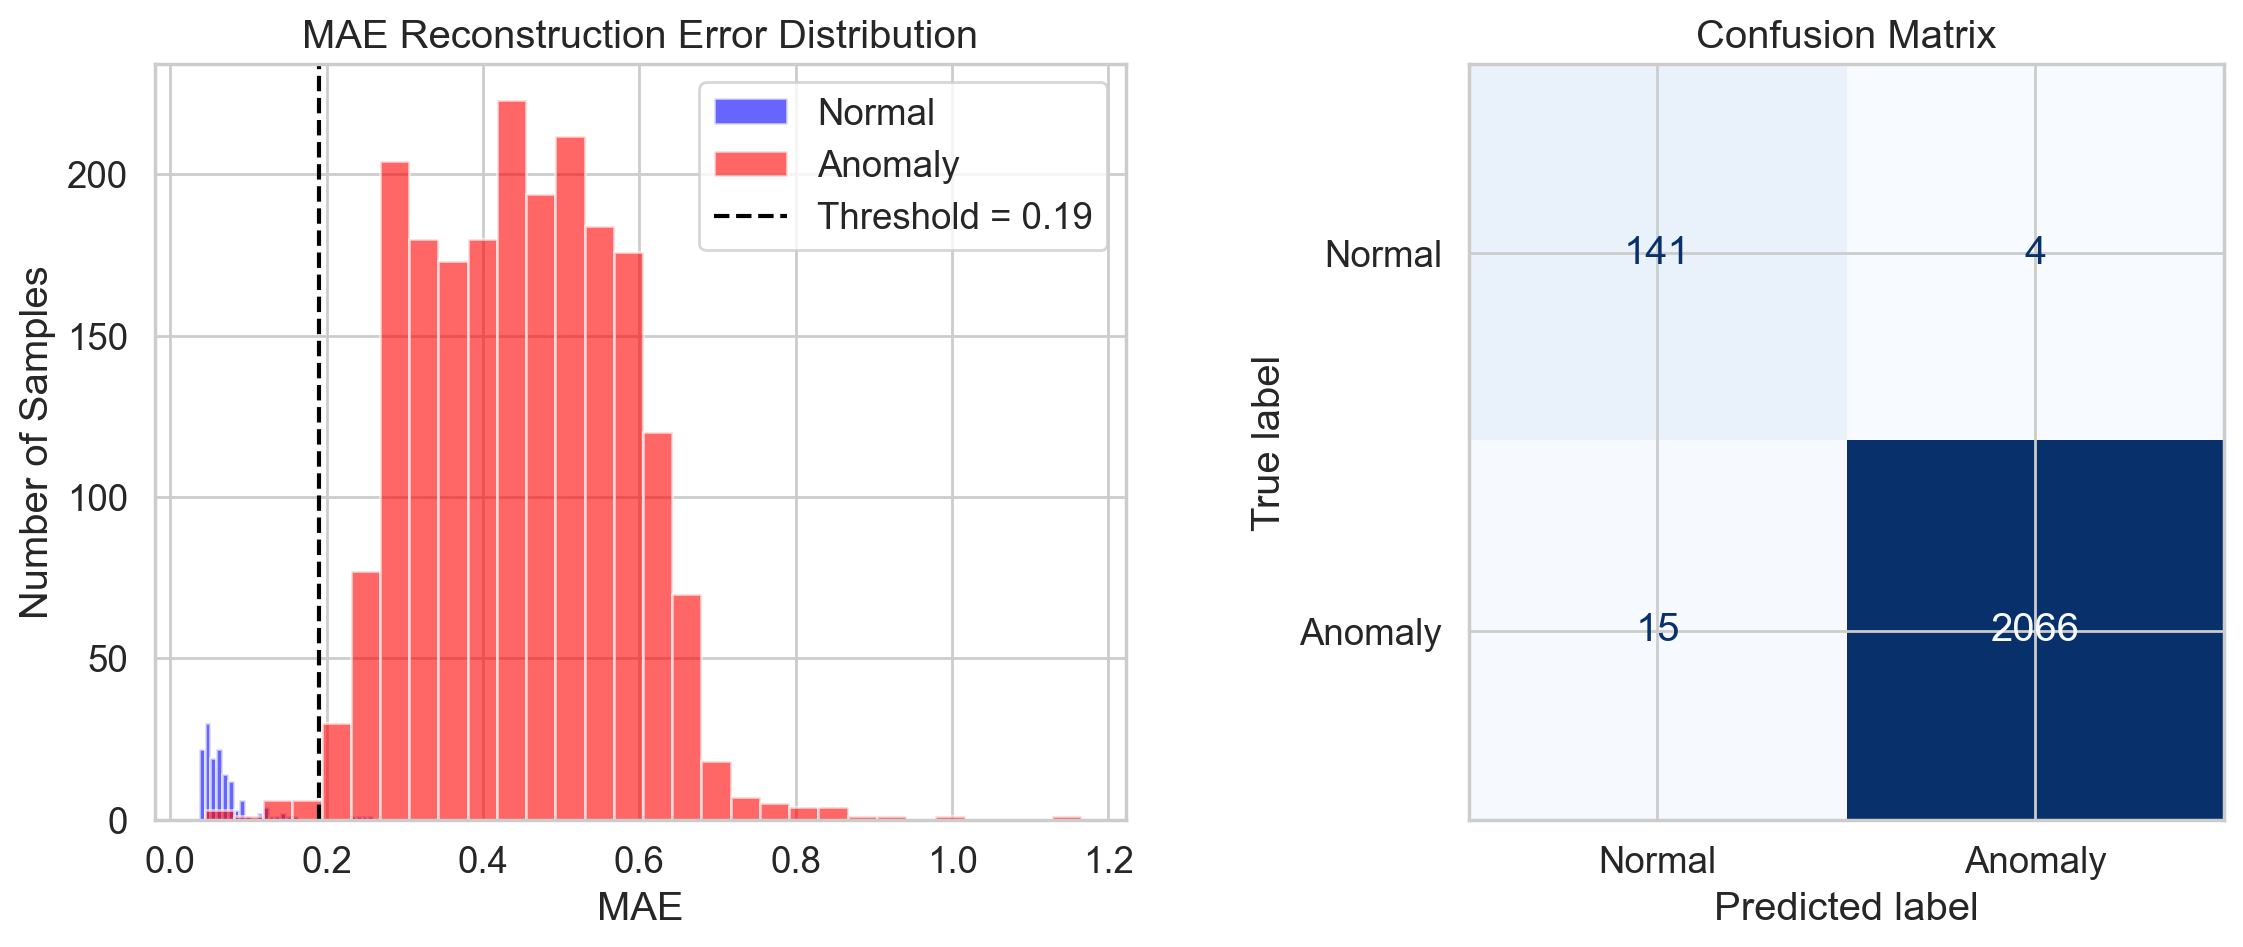

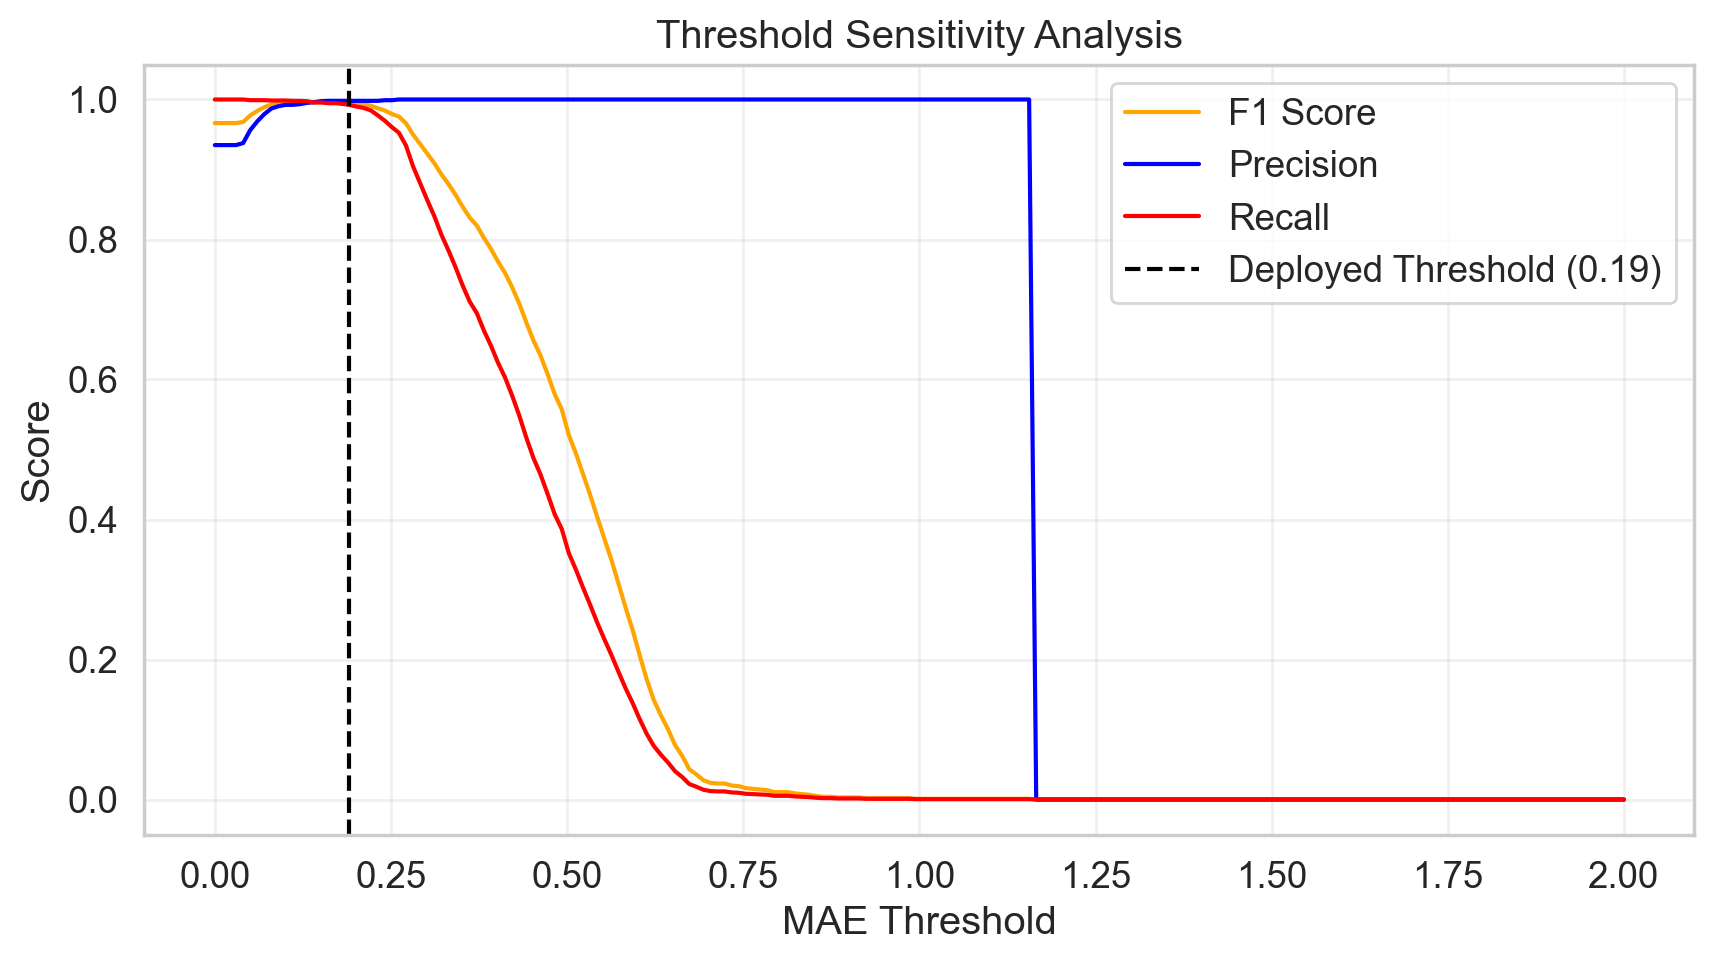

In [42]:
# MAE Distribution and Confusion Matrix Visualisation
plt.figure(figsize=(12, 5))

# MAE Distribution
plt.subplot(1,2,1)
plt.hist(normal_mae, bins=30, alpha=0.6, color='blue', label='Normal')
plt.hist(anomaly_mae, bins=30, alpha=0.6, color='red', label='Anomaly')
plt.axvline(THRESHOLD, color='black', linestyle='--', label=f'Threshold = {THRESHOLD:.2f}')
plt.title('MAE Reconstruction Error Distribution')
plt.xlabel('MAE')
plt.ylabel('Number of Samples')
plt.legend()

# Confusion Matrix Heatmap
plt.subplot(1,2,2)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Anomaly"])
disp.plot(ax=plt.gca() , cmap="Blues", colorbar=False)
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

# Threshold Sensitivity Analysis
thresholds = np.linspace(0, 2.0 , 200)
f1_scores, precisions, recalls = [], [], []

for t in thresholds:
    y_pred_t = (all_mae > t).astype(int)
    
    # calculate metrics 
    precision = precision_score(y_true, y_pred_t, zero_division=0)
    recall = recall_score(y_true, y_pred_t, zero_division=0)
    f1 = f1_score(y_true, y_pred_t, zero_division=0)
    precisions.append(precision)
    recalls.append(recall)
    f1_scores.append(f1)

plt.figure(figsize=(10, 5))
plt.plot(thresholds, f1_scores, label='F1 Score', color='orange')
plt.plot(thresholds, precisions, label='Precision', color='blue')
plt.plot(thresholds, recalls, label='Recall', color='red')
plt.axvline(THRESHOLD, color='black', linestyle='--', label=f'Deployed Threshold ({THRESHOLD:.2f})')
plt.title('Threshold Sensitivity Analysis')
plt.xlabel('MAE Threshold')
plt.ylabel('Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


